# Import Library

In [ ]:
import pathlib
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import random
from glob import glob
import matplotlib.image as img
import zipfile
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
import tensorflow as tf
print(tf.__version__)

2.18.0


# Merge Dataset

In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
from pathlib import Path

source_root = Path("/content/drive/MyDrive/dlpcm_folder/dataset/Diagnosis of Diabetic Retinopathy")
output_root = Path("/content/drive/MyDrive/dlpcm_folder/merge_dataset")

# Create output folders for 'DR' and 'No_DR'
(output_root / 'DR').mkdir(parents=True, exist_ok=True)
(output_root / 'No_DR').mkdir(parents=True, exist_ok=True)

# Function to copy files from source to destination
def copy_files(from_folder, label):
    for file in from_folder.glob("*"):
        if file.is_file():
            print(f"Copying {file.name} from {from_folder} to {label}")
            shutil.copy(file, output_root / label)

# Dataset subsets (train, valid, test)
subsets = ['train', 'valid', 'test']
labels = ['DR', 'No_DR']  # must match folder names exactly

for subset in subsets:
    for label in labels:
        source_folder = source_root / subset / label
        if not source_folder.exists():
            print(f"Folder not found: {source_folder}")
        else:
            copy_files(source_folder, label)

print("Merging completed.")

# Load Dataset

In [ ]:
path = '/content/drive/MyDrive/dlpcm_folder/merge_dataset'

for file_name in os.listdir(path):
    print(file_name)

DR
No_DR


In [ ]:
counter = 0

dir_names=['DR', 'No_DR']
for file in (dir_names):
    dir = os.listdir(f"{path}/{file}")

    print(f"Data for {file} is {len(dir)}")

Data for DR is 1408
Data for No_DR is 1430


# Dataset Augmentation

In [ ]:
!pip install augmentor

In [ ]:
import Augmentor
from PIL import Image
import os

for i in dir_names:
    input_dir = f"/content/drive/MyDrive/dlpcm_folder/merge_dataset/{i}"
    output_dir = f'/content/drive/MyDrive/dlpcm_folder/augmented_dataset/{i}'
    p = Augmentor.Pipeline(input_dir, output_directory=output_dir)

    # Convert images to RGB before applying operations
    image_paths = [os.path.join(input_dir, filename) for filename in os.listdir(input_dir) if filename.endswith(('.jpg', '.jpeg', '.png'))]
    for image_path in image_paths:
        img = Image.open(image_path)
        if img.mode != 'RGB':
            img = img.convert('RGB')
            img.save(image_path)  # Overwrite the original image with the RGB version

    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.flip_left_right(probability=0.5)
    p.flip_top_bottom(probability=0.5)
    p.zoom_random(probability=0.5, percentage_area=0.8)
    p.crop_random(probability=0.5, percentage_area=0.8)
    p.resize(probability=1.0, width=150, height=150)
    p.random_brightness(probability=0.5, min_factor=0.7, max_factor=1.3)
    p.random_contrast(probability=0.5, min_factor=0.8, max_factor=1.2)
    p.set_save_format(save_format='PNG')  # Change the save format to PNG to support RGBA images
    p.sample(3000)

Initialised with 1408 image(s) found.
Output directory set to /content/drive/MyDrive/dlpcm_folder/augmented_dataset/DR.

Processing <PIL.Image.Image image mode=RGB size=150x150 at 0x7B6CEF4F3550>: 100%|██████████| 3000/3000 [01:18<00:00, 38.45 Samples/s]


Initialised with 1430 image(s) found.
Output directory set to /content/drive/MyDrive/dlpcm_folder/augmented_dataset/No_DR.

Processing <PIL.Image.Image image mode=RGB size=150x150 at 0x7B6CDC27C610>: 100%|██████████| 3000/3000 [01:17<00:00, 38.85 Samples/s]


In [ ]:
input_dir = '/content/drive/My Drive/capstone project/ML/Dental diseases_Model'
output_dir = '/content/drive/My Drive/capstone project/ML/Final Dataset'

## Check Data

In [ ]:
path = pathlib.Path('/content/drive/MyDrive/dlpcm_folder/augmented_dataset')

image_count_train = len(list(path.glob('*/*.*')))  # Mengambil semua file dengan ekstensi apa pun
print(f"Total image count (all file types): {image_count_train}")

Total image count (all file types): 6000


In [ ]:
counter = 0
for file in (dir_names):
    dir = os.listdir(f"{path}/{file}")

    print(f"Data for {file} is {len(dir)}")

Data for DR is 3000
Data for No_DR is 3000


# Split Data Into Training and Validation

In [ ]:
import logging

logging.basicConfig(level=logging.INFO)

path = '/content/drive/MyDrive/dlpcm_folder/augmented_dataset'

def validate_and_remove_images(path):
    for root, dirs, files in os.walk(path):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                # Try to decode the image using TensorFlow
                img = tf.io.read_file(file_path)
                img = tf.image.decode_image(img, channels=3)
            except Exception as e:
                print(f"Error decoding image {file_path}: {e}")
                # If decoding fails, remove or handle the file
                os.remove(file_path)  # Remove the file
                print(f"Removed: {file_path}")

# Run the validation and removal function
validate_and_remove_images(path)

# Recreate your datasets after removing invalid files
batch_size=16
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  path,
  shuffle=True,
  seed=123,
  validation_split = 0.3,
  subset = 'training',
  image_size=(224, 224),
  batch_size=batch_size)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  path,
  shuffle=True,
  seed=123,
  validation_split = 0.3,
  subset = 'validation',
  image_size=(224,224),
  batch_size=batch_size)

Found 6000 files belonging to 2 classes.
Using 4200 files for training.
Found 6000 files belonging to 2 classes.
Using 1800 files for validation.


In [ ]:
validation_size = int(0.5 * val_ds.cardinality().numpy())
test_ds = val_ds.take(validation_size)
val_ds = val_ds.skip(validation_size)

In [ ]:
print("Training Set Size: %d" % train_ds.cardinality().numpy())
print("Validation Set Size: %d" % val_ds.cardinality().numpy())
print("Test Set Size: %d" % test_ds.cardinality().numpy())

Training Set Size: 263
Validation Set Size: 57
Test Set Size: 56


In [ ]:
def count_images(dataset):
    total = 0
    for batch in dataset:
        images, labels = batch
        total += images.shape[0]
    return total

train_count = count_images(train_ds)
val_count = count_images(val_ds)
test_count = count_images(test_ds)

print("\nNumber of images:")
print(f"Training: {train_count}")
print(f"Validation: {val_count}")
print(f"Test: {test_count}")


Number of images:
Training: 4200
Validation: 904
Test: 896


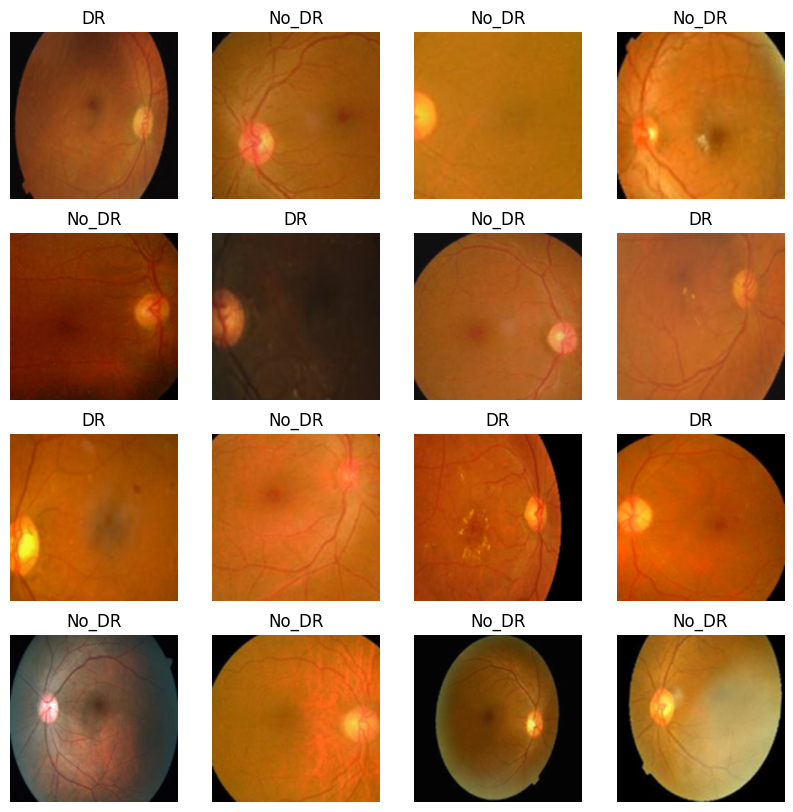

In [ ]:
for images, labels in train_ds.take(1):
    batch_size = images.shape[0]
    num_images_to_display = min(batch_size, 25)

    plt.figure(figsize=(10, 10))
    for i in range(num_images_to_display):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(dir_names[labels[i].numpy()])
        plt.axis("off")
    plt.show()

# Set Parameter

In [ ]:
IMG_SIZE = (224,224)
IMG_SHAPE = IMG_SIZE + (3,)

# Use Transfer Learning

## DenseNet121

In [ ]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, Adamax

base_model=tf.keras.applications.DenseNet121(include_top=False, weights="imagenet",input_shape=IMG_SHAPE, pooling='max')
x = base_model.output

# Normalization layer
x = tf.keras.layers.BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001)(x)

x = Dense(128,
          kernel_regularizer=regularizers.l2(0.001),
          activity_regularizer=regularizers.l1(0.001),
          bias_regularizer=regularizers.l1(0.001),
          activation='relu')(x)
x = Dropout(rate=0.3, seed=123)(x)

output = Dense(1, activation='sigmoid')(x)
model = Model(inputs=base_model.input, outputs=output)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
learning_rate = 0.0005

model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adamax(learning_rate=learning_rate),
              metrics=['accuracy'])

# Set Callback

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Callback untuk menurunkan learning rate saat val_loss stagnan
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

# Callback untuk menghentikan training saat val_accuracy mencapai 99%
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get('val_accuracy') is not None and logs.get('val_accuracy') >= 0.99:
            print("\nReached 99% validation accuracy. Stopping training.")
            self.model.stop_training = True

# Gabungkan semua callback ke dalam satu list
callbacks = [myCallback(), reduce_lr]

In [ ]:
initial_epochs = 20
history = model.fit(train_ds, validation_data=val_ds, epochs=initial_epochs, callbacks=[callbacks])

Epoch 1/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 290s 519ms/step - accuracy: 0.8229 - loss: 1.2759 - val_accuracy: 0.9436 - val_loss: 0.8653 - learning_rate: 5.0000e-04
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.9497 - loss: 0.6352 - val_accuracy: 0.9635 - val_loss: 0.5629 - learning_rate: 5.0000e-04
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.9590 - loss: 0.5451 - val_accuracy: 0.9591 - val_loss: 0.5260 - learning_rate: 5.0000e-04
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.9748 - loss: 0.4912 - val_accuracy: 0.9657 - val_loss: 0.4618 - learning_rate: 5.0000e-04
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.9809 - loss: 0.4344 - val_accuracy: 0.9723 - val_loss: 0.4267 - learning_rate: 5.0000e-04
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.9774 - loss: 0.4055 - val_accuracy: 0.9524 - val_loss: 0.4437 - learning_rate: 5.0000e-04
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/s

# Save Model

In [ ]:
model.save('/content/drive/MyDrive/dlpcm_folder/model/model_with_densenet_224x224.h5')

# Plot Training and Validation

Text(0.5, 1.0, 'Training vs Validation Loss')

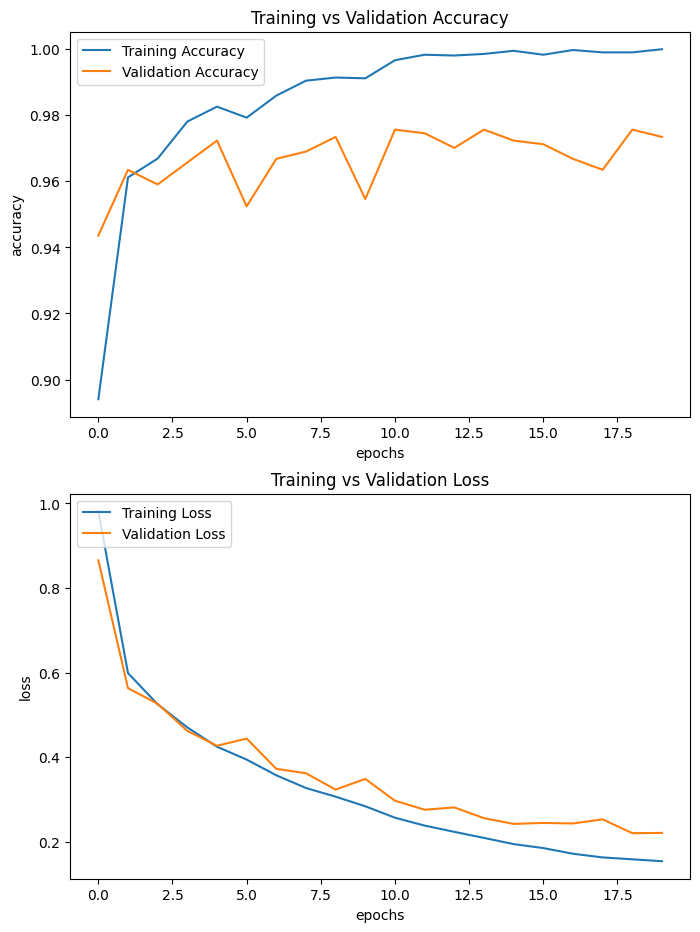

In [ ]:
acc = history.history['accuracy']
loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 11))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(loc='upper left')
plt.title('Training vs Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(loc='upper left')
plt.title('Training vs Validation Loss')

# Evaluate Model

In [ ]:
model.evaluate(test_ds)

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9843 - loss: 0.1724


[0.17188520729541779, 0.9877232313156128]

# Test Model

In [ ]:
print(train_ds.class_names)
label = train_ds.class_names

['DR', 'No_DR']


In [ ]:
from tensorflow.keras.models import load_model
from google.colab import files
from tensorflow.keras.utils import load_img, img_to_array

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
model = load_model('/content/drive/My Drive/capstone project/ML/model/model_with_densenet_224x224.h5')

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 21,347,397 (81.43 MB)

 Trainable params: 7,087,233 (27.04 MB)

 Non-trainable params: 85,696 (334.75 KB)

 Optimizer params: 14,174,468 (54.07 MB)

In [ ]:
model.evaluate(test_ds)

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9812 - loss: 0.1810


[0.1783779412508011, 0.9854910969734192]

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import os

# Labels for binary classification with sigmoid
labels = ['DR', 'No_DR']  # DR = 1, No_DR = 0

# Folder with test images
folder_path = '/content/drive/MyDrive/dlpcm_folder/data_test'
target_size = (150, 150)  # Match model input size

# Loop through all image files
for filename in os.listdir(folder_path):
    if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        path = os.path.join(folder_path, filename)
        img = load_img(path, target_size=target_size)
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)
        images = np.vstack([x])

        # Predict
        prediction = model.predict(images, batch_size=10)[0][0]  # Only one output for sigmoid

        # Calculate both DR and No_DR probabilities
        dr_prob = prediction
        nodr_prob = 1 - prediction

        dr_percent = round(dr_prob * 100)
        nodr_percent = round(nodr_prob * 100)

        # Output results
        print(f"\n📁 File: {filename}")
        print(f"DR: {dr_percent}% accuracy")
        print(f"No_DR: {nodr_percent}% accuracy")

        if dr_prob > 0.5:
            print(f"➡️ You Are Diagnosed With DR With {dr_percent}% accuracy\n")
        elif nodr_prob > 0.5:
            print(f"➡️ You Are Diagnosed With No_DR With {nodr_percent}% accuracy\n")
        else:
            print("❌ Not Detected!\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

📁 File: data_dr.jpg
DR: 2% accuracy
No_DR: 98% accuracy
➡️ You Are Diagnosed With No_DR With 98% accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

📁 File: data_nodr.jpg
DR: 99% accuracy
No_DR: 1% accuracy
➡️ You Are Diagnosed With DR With 99% accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

📁 File: dr1.jpg
DR: 5% accuracy
No_DR: 95% accuracy
➡️ You Are Diagnosed With No_DR With 95% accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

📁 File: nodr1.jpg
DR: 3% accuracy
No_DR: 97% accuracy
➡️ You Are Diagnosed With No_DR With 97% accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

📁 File: dr2.jpg
DR: 64% accuracy
No_DR: 36% accuracy
➡️ You Are Diagnosed With DR With 64% accuracy

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step

📁 File: nodr2.jpg
DR: 89% accuracy
No_DR: 11% accuracy
➡️ You Are Diagnosed With DR With 89% accuracy



# Deploy to TFLite

In [ ]:
tf_lite_converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = tf_lite_converter.convert()

Saved artifact at '/tmp/tmp51q41thj'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  139415982581776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139415982581968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139415982581200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139415982582160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139415982582544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139415982579472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139415982580048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139415982583120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139415982582736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139415982584848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13941598258676

In [ ]:
tflite_name = 'tf_lite_model_densenet_224_sigmoid.tflite'

with open(tflite_name, 'wb') as f:
  f.write(tflite_model)